# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Мовсумова Марина

# План работы

**Цель проекта**:

Построить модель, которая прогнозирует вероятность оттока клиента (churn) в следующем месяце, чтобы компания могла заранее выявлять клиентов с риском ухода

**Задачи проекта**:

- Провести исследовательский анализ данных (EDA)
- Подготовить данные: обработать пропуски и признаки
- Построить модель логистической регрессии
- Оценить качество модели с помощью метрик 
- Улучшить модель за счёт отбора и создания признаков
- Подобрать гиперпараметры
- Обучить финальную модель и сохранить её вместе с пайплайном

# Постановка задачи машинного обучения

Необходимо решить задачу машинного обучения для прогнозирования вероятности оттока клиентов сервиса доставки кофе.

Тип задачи машинного обучения: бинарная классификация.

Целевая переменная: факт оттока клиента (столбец churn датафрейма), где 1 — клиент ушёл, 0 — клиент остался.

Модель должна быть линейной, чтобы обеспечить интерпретируемость результатов и возможность анализа влияния признаков на отток клиентов.

Основная метрика — Precision-Recall AUC (PR-AUC), так как данные могут быть несбалансированы, и важно корректно выявлять клиентов, склонных к уходу.

Дополнительные метрики — ROC-AUC, Precision, Recall, F1-мера.

Для успешного решения задачи необходимо достичь качества модели, превосходящего базовую модель (DummyClassifier), и обеспечить разумный баланс между точностью и полнотой.

Данные будут разделены на обучающую и тестовую выборки с использованием кросс-валидации для оценки устойчивости модели.

# Оглавление

1. [Этап 1. Подготовка среды и библиотек](#section1)
2. [Этап 2. Первичный анализ данных](#section2)
3. [Этап 3. Предобработка данных](#section3)
4. [Этап 4. Обучение модели](#section4)
5. [Этап 5. Создание новых признаков](#section5)
6. [Этап 6. Эксперименты с гиперпараметрами](#section6)
7. [Этап 7. Подготовка финальной модели](#section7)
8. [Этап 8. Отчёт о проделанной работе](#section8)
9. [Этап 9. Сохранение модели для продакшена](#section9)

<a id='section1'></a>
## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
%pip install -r requirements.txt

  Using cached fqdn-1.5.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached isoduration-20.11.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached uri_template-1.3.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached webcolors-25.10.0-py3-none-any.whl.metadata (2.2 kB)
Using cached webcolors-25.10.0-py3-none-any.whl (14 kB)
Using cached fqdn-1.5.1-py3-none-any.whl (9.1 kB)
Using cached isoduration-20.11.0-py3-none-any.whl (11 kB)
Using cached uri_template-1.3.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [isoduration]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import sklearn
import matplotlib
import seaborn
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

In [3]:
random_state = 42

In [4]:
df = pd.read_csv('coffee_churn_dataset.csv', sep=",", decimal='.')

<a id='section2'></a>
## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [6]:
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Данные представляют собой агрегированную информацию о пользователях сервиса доставки кофе за последние 4 недели. Каждая строка соответствует одному уникальному клиенту.

В датасете содержатся признаки, характеризующие поведение пользователей:
- активность (частота заказов, количество открытий приложения),
- финансовые показатели (средний чек, сумма покупок),
- взаимодействие с сервисом (использование скидок, уведомлений, наличие сбоев приложения),
- предпочтения (тип кофе, обжарка, размер напитка, тип молока),
- а также технические и региональные характеристики (тип устройства, регион).

Большинство признаков являются потенциально информативными для задачи прогнозирования оттока, так как отражают активность и вовлечённость клиента. Однако в датасете также есть признаки, которые определенным образом дублируют друг друга: avg_order_value и median_order_value, order_frequency_week и order_frequency_month, total_spent_last_week и total_spent_last_month. Такие признаки могут быть потенциально избыточными и могут сильно коррелировать между собой, что, в свою очередь, может привести к мультиколлинеарности при обучении линейной модели. В целях её снижения признаки median_order_value, order_frequency_week и total_spent_last_week будут удалены.

Признак user_id не несёт полезной информации для модели, так как является уникальным идентификатором пользователя и не связан с его поведением, его можно удалить.

In [7]:
df = df.drop(columns=['user_id', 'median_order_value', 'order_frequency_week', 'total_spent_last_week'])

In [8]:
clients_df = pd.DataFrame({
    'abs': df['churn'].value_counts(),
    'real': df['churn'].value_counts(normalize=True)
})

clients_df

,abs,real
churn,,
0,9821,0.939809
1,629,0.060191


Целевая переменная -- столбец churn, отражает факт оттока клиентов:
1 -- клиент перестал пользоваться сервисом,
0 -- клиент остался.

Анализ распределения показал, что классы распределены неравномерно: доля клиентов, оставшихся в сервисе, значительно превышает долю ушедших клиентов. Таким образом, наблюдается дисбаланс классов.

In [9]:
missing_df = pd.DataFrame({
    'abs': df.isna().sum(),
    'real': round(df.isna().mean(), 3)
})

missing_df

,abs,real
days_since_last_order,945,0.090
order_frequency_month,600,0.057
avg_order_value,583,0.056
total_spent_last_month,294,0.028
discount_usage_rate,397,0.038
last_coffee_type,258,0.025
preferred_roast,116,0.011
milk_preference,668,0.064
seasonal_menu_tried,989,0.095
coffee_bean_origin,682,0.065


В датасете присутствуют пропущенные значения как в числовых, так и в категориальных признаках.
Доля пропусков варьируется примерно от 1% до 10% в разных столбцах.
Наибольшая доля пропущенных значений (около 8–10%) наблюдается в признаках, связанных с активностью пользователей и взаимодействием с сервисом (например, seasonal_menu_tried (9.5%), days_since_last_order (9%), total_spent_last_week (9%), subscription_status (9%) и тд.
В ряде признаков доля пропусков невысока (около 1–3%) (preferred_roast (1.1%), geo_location(1.1%), last_coffee_type(2.5%), total_spent_last_month (2.8%)), а в целевой переменной и идентификаторе пользователя пропуски отсутствуют.

Удаление строк в таком количестве кажется нецелесообразным, так как есть опасность потерять значимое количество данных. В связи с этим пропуски в числовых признаках будут заполнены, а сами признаки масштабированы (StandardScaler / MinMaxScaler) и заполнены медианным значением. Пропуски в категориальных признаках будут заполнены наиболее частым значением (модой) и сдалее признаки будут закодированы (OneHotEncoder).

Некоторые признаки могут быть использованы для создания новых, более информативных.

Например, средние чеки пользователей за год: 
- total_spent_last_month / order_frequency_month 
  
Или интенсивность активности и общаяя вовлеченность:
- app_opens_per_week * order_frequency_week
  
Кроме того, после изучения распределения признаков, можно подумать о применении квадратного корня к признакам со скошенным распределением. 

In [10]:
df.describe()

,days_since_last_order,order_frequency_month,avg_order_value,total_spent_last_month,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,9867.000000,10156.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,1063.741207,1946.132979,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,707.713396,2370.619590,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-32.075932,-43.716463,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,552.898663,629.680382,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,898.643524,1300.409757,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1406.332153,2481.650495,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,5901.965278,79298.849570,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [11]:
temp = df.copy() #копия датасета до преобразования для возможности проверить сделанные изменения после обработки

In [12]:
num_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week'
]
mask_errors = (df[num_features] < 0).any(axis=1)

errors_total = mask_errors.sum()

errors_total

np.int64(8)

In [13]:
df = df[~(df[num_features] < 0).any(axis=1)]

In [14]:
a, b = len(temp), len(df)
print(" Было строк в датасете до фильтрации", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в датасете до фильтрации 10450 
 Осталось строк в датасете после обработки 10442 
 Удалено строк в датасете после обработки 8 
 Процент потерь 0.08


В ходе анализа данных были выявлены некорректные значения в ряде числовых признаков, в частности отрицательные значения в показателях, где они невозможны по смыслу (например, суммы трат, частота заказов, количество открытий приложения и оценки пользователей).

Такие значения были интерпретированы как ошибки данных, поскольку они противоречат логике предметной области.

Доля строк, содержащих хотя бы одно некорректное значение, составила около 0.8% от общего объёма данных. Учитывая небольшую долю таких наблюдений, было принято решение удалить соответствующие строки из выборки, чтобы избежать искажения распределений признаков и повышения шума в данных.

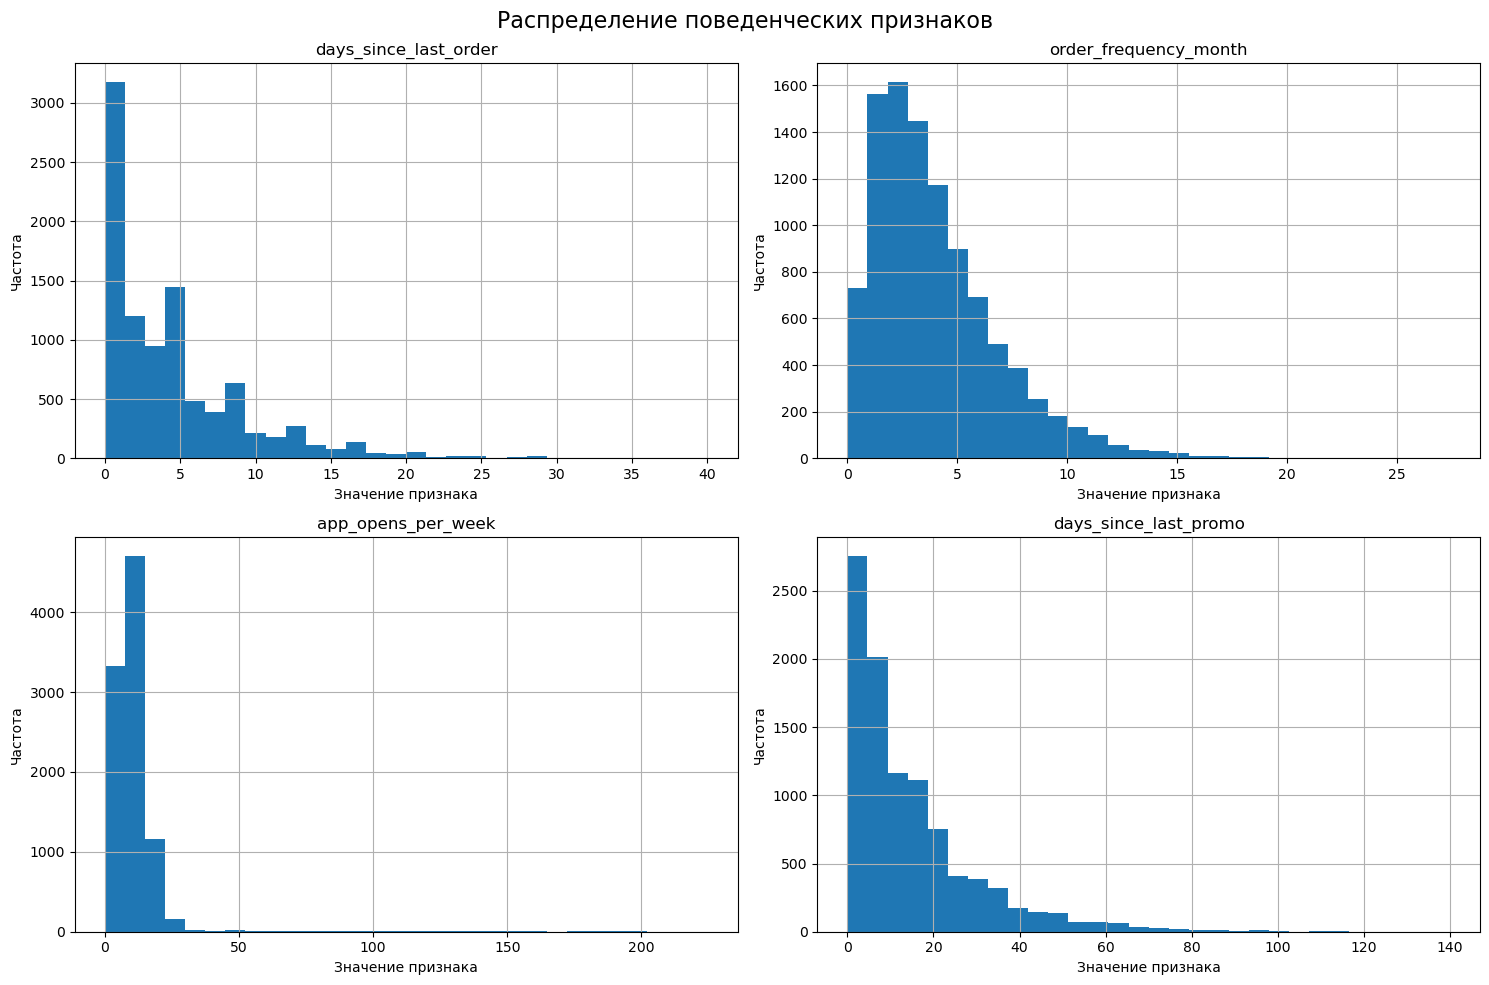

In [15]:
behavior_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'app_opens_per_week',
    'days_since_last_promo'
]

axes = df[behavior_cols].hist(figsize=(15, 10), bins=30)

for ax in axes.flatten():
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение поведенческих признаков', fontsize=16)
plt.tight_layout()
plt.show()

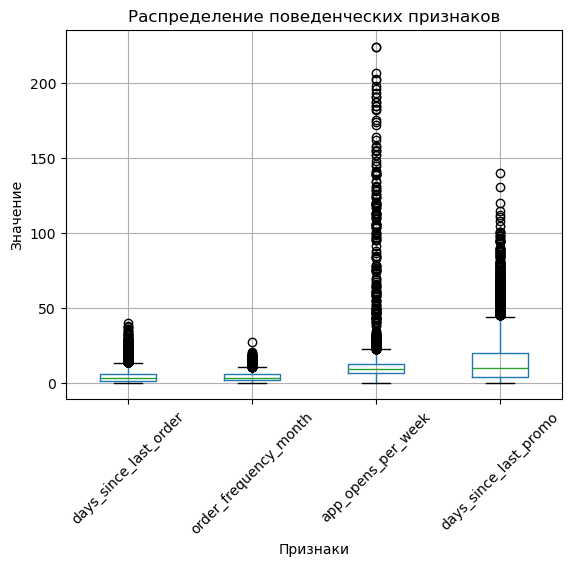

In [16]:
df[behavior_cols].boxplot(rot=45)

plt.title('Распределение поведенческих признаков')
plt.xlabel('Признаки')
plt.ylabel('Значение')

plt.show()

Распределения поведенческих признаков показывают, что большинство из них имеют правостороннюю асимметрию: основная масса значений сосредоточена в области небольших значений, при этом наблюдаются длинные «хвосты» справа.
выбросы. Наиболее выраженные выбросы наблюдаются в признаках, связанных с активностью пользователей (app_opens_per_week) и давностью использования акций (days_since_last_promo). При этом выбросы не являются единичными и, вероятно, отражают реальные особенности поведения пользователей, поэтому их удаление нецелесообразно. Для уменьшения влияния асимметрии может быть рассмотрено применение логарифмического преобразования.

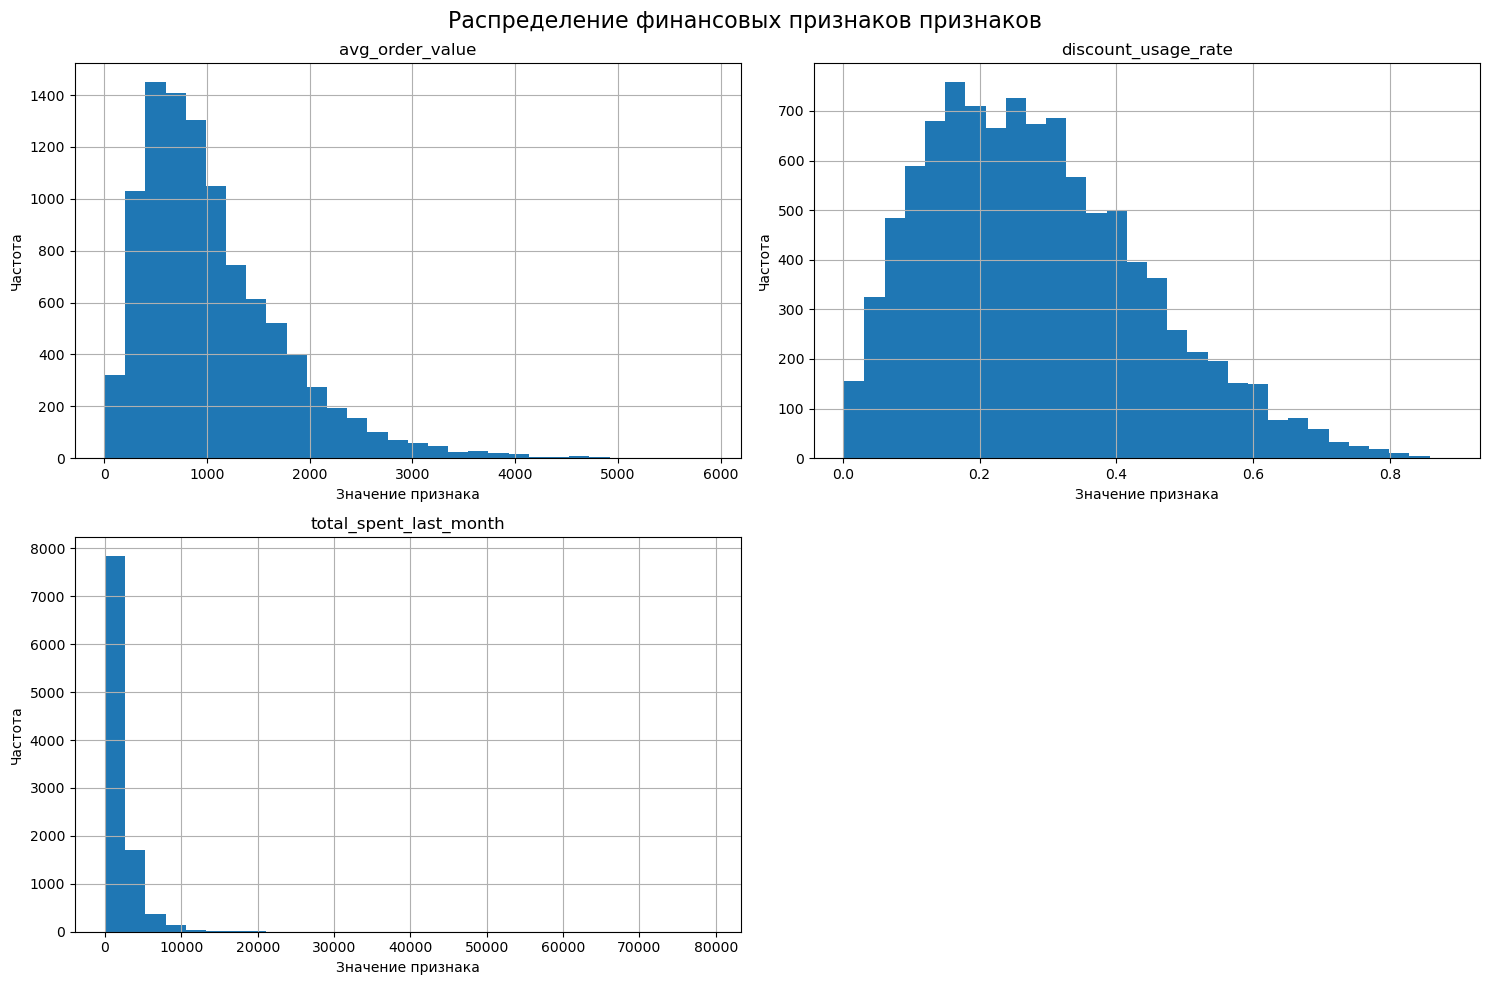

In [17]:
financial_cols = [
    'avg_order_value',
    'discount_usage_rate',
    'total_spent_last_month'
]

axes = df[financial_cols].hist(figsize=(15, 10), bins=30)

for ax in axes.flatten():
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение финансовых признаков признаков', fontsize=16)
plt.tight_layout()
plt.show()

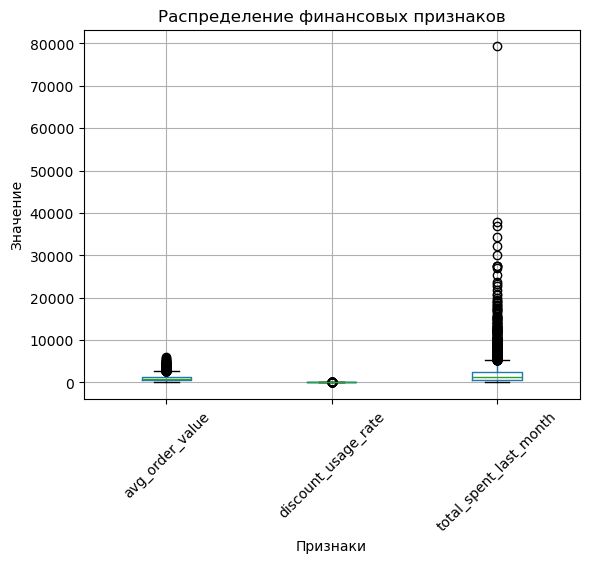

In [18]:
df[financial_cols].boxplot(rot=45)

plt.title('Распределение финансовых признаков')
plt.xlabel('Признаки')
plt.ylabel('Значение')

plt.show()

Анализ распределений финансовых признаков показал, что большинство из них также имеют правостороннюю асимметрию. Основная масса значений сосредоточена в области небольших и средних значений, при этом наблюдаются длинные правые «хвосты».

Наиболее выраженные выбросы наблюдаются в признаке total_spent_last_month, где присутствуют значения, значительно превышающие основную часть распределения. Однако даже такое значение может быть естественным поведением пользователя (например, корпоративный клиент или заказ на мероприятие), так что было принято решение его оставить. Для снижения влияния ассиметрии в дальнейшем будут применены нелинейные преобразования признаков (извлечение корня). 

In [19]:
interval_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

phik_corr = df.phik_matrix(interval_cols=interval_cols, bins=10)

phik_corr['churn'].sort_values(ascending=False)

churn                       1.000000
app_crashes_last_month      0.853747
app_opens_per_week          0.126077
subscription_status         0.105250
order_frequency_month       0.079240
geo_location                0.038563
review_rating_last_10       0.033892
avg_order_value             0.031445
discount_usage_rate         0.027838
total_spent_last_month      0.025709
phone_type                  0.005151
last_coffee_type            0.004432
days_since_last_order       0.000000
preferred_roast             0.000000
milk_preference             0.000000
notifications_enabled       0.000000
seasonal_menu_tried         0.000000
coffee_bean_origin          0.000000
last_drink_size             0.000000
days_since_last_promo       0.000000
seasons                     0.000000
review_rating_last_1        0.000000
coffee_preference_change    0.000000
Name: churn, dtype: float64

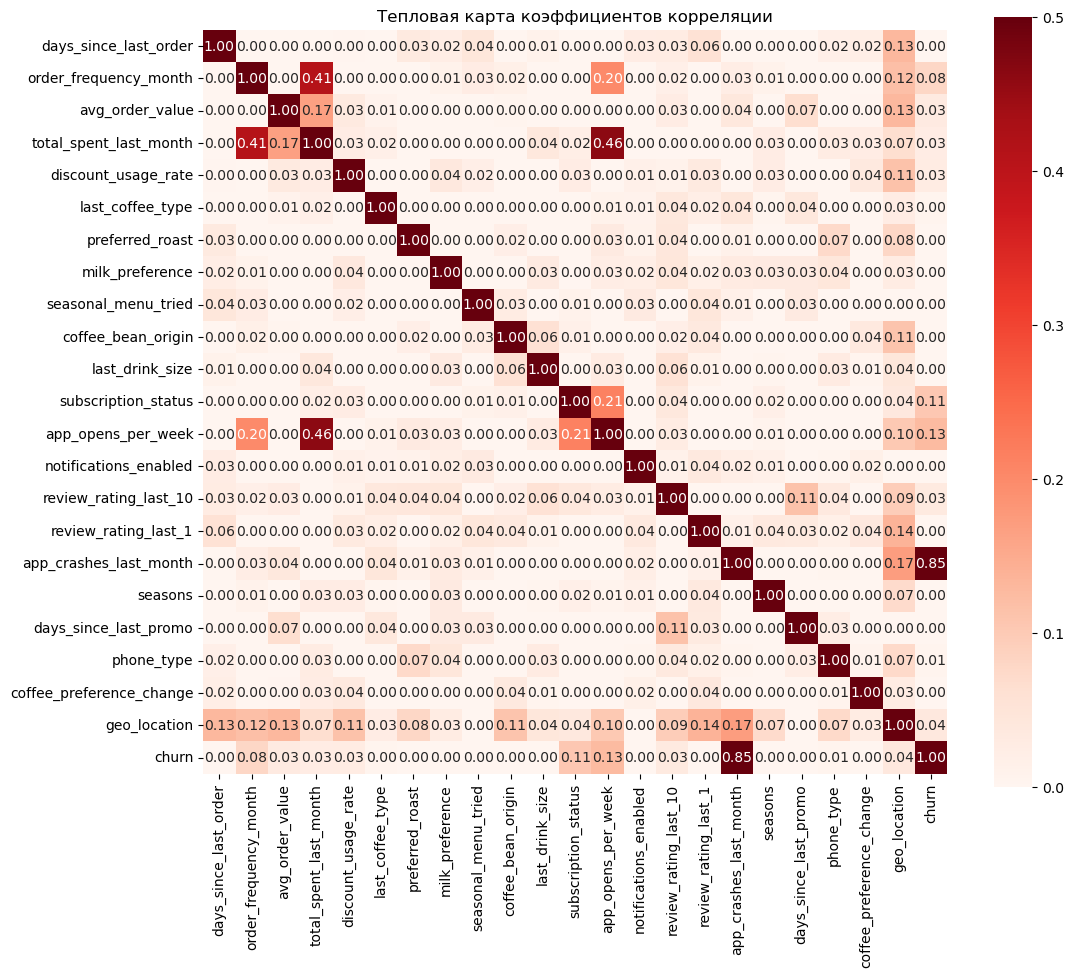

In [20]:
plt.figure(figsize=(12,10))

sns.heatmap(
    phik_corr,
    annot=True,
    cmap='Reds',
    fmt=".2f",
    square=True,
    vmin=0,
    vmax=0.5
)

plt.title('Тепловая карта коэффициентов корреляции')
plt.show()

import warnings
warnings.filterwarnings('ignore')

Анализ корреляции признаков с целевой переменной показал, что наибольшую связь с оттоком клиентов демонстрирует показатель app_crashes_last_month (коэффициент 0.85), что указывает на сильную зависимость между частотой сбоев приложения и вероятностью ухода клиента.

Остальные признаки имеют значительно более слабую связь с целевой переменной. Среди них можно выделить app_opens_per_week, subscription_status, order_frequency_month и total_spent_last_month, однако их корреляция остаётся на низком уровне (менее 0.15).

Большинство признаков демонстрируют нулевую или практически нулевую корреляцию с оттоком. Это может указывать на отсутствие линейной зависимости либо на наличие более сложных, нелинейных взаимосвязей, которые не выявляются с помощью корреляционного анализа.

Таким образом, можно сделать вывод, что отдельные признаки по отдельности слабо объясняют отток клиентов, за исключением частоты сбоев приложения, и для построения эффективной модели требуется учитывать совокупность признаков и их взаимодействие.

<a id='section3'></a>
## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [21]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

In [22]:
cat_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'seasonal_menu_tried',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'notifications_enabled',
    'seasons',
    'phone_type',
    'coffee_preference_change',
    'geo_location'
]

num_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week'
]

In [23]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
 <font color='4682B4'> Я не очень понимаю формулировку задания тут. Написано создать пайплайн, который проведет масштабирование И нормализацию, но разве нормализация -- это не тип масштабирования? Я рискнула сделать стандартизацию, а не MinMaxScaler, потому что в данных все ещё есть выбросы, которые кажутся нормальным поведением пользователей, а StandardScaler к ним менее чувствителен.
 Кроме того, я не очень понимаю, зачем создавать отдельный пайплайн для выбросов и пропусков, если пропуски необходимо обработать в зависимости от типа признаков (вроде как нельзя обработать пропуски в категориальных данных так же, как и в числовых, только если речь не про удаление).</font>
 </div>

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_features),
        ('num', num_pipe, num_features)
    ]
)

<a id='section4'></a>
## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [25]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    baseline_model,
    X_train,
    y_train,
    scoring=['average_precision','roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_df

,pr_auc,roc_auc,precision,recall,f1
0,0.060443,0.5,0.0,0.0,0.0
1,0.060443,0.5,0.0,0.0,0.0
2,0.060443,0.5,0.0,0.0,0.0
3,0.059880,0.5,0.0,0.0,0.0
4,0.059880,0.5,0.0,0.0,0.0


Базовая модель была обучена с использованием стратифицированной кросс-валидации.

По результатам оценки качества получены следующие значения метрик: ROC-AUC ≈ 0.5, PR-AUC ≈ 0.06, precision = 0, recall = 0 и F1 = 0.

Значение ROC-AUC, равное 0.5, указывает на то, что модель не способна различать классы. Нулевые значения precision, recall и F1-меры свидетельствуют о том, что модель не предсказывает ни одного случая оттока.

Значение PR-AUC близко к доле положительного класса в выборке (около 6%), что подтверждает отсутствие способности модели выявлять клиентов, склонных к уходу.

Такие результаты объясняются тем, что модель всегда предсказывает наиболее частый класс (отсутствие оттока), игнорируя редкий класс. 

<a id='section5'></a>
## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [26]:
df_fe = df.copy() #копия датасета для создания дополнительных признаков

In [27]:
#модель логистической регрессии без новых признаков

logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model,
    X_train,
    y_train,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1'],
})

cv_summary = pd.DataFrame({
    'mean': cv_df.mean(),
    'std': cv_df.std()
}).round(3)

print(cv_df)

print(cv_summary)

     pr_auc   roc_auc  precision    recall        f1
0  0.640459  0.939907   0.688525  0.415842  0.518519
1  0.658261  0.895926   0.769231  0.495050  0.602410
2  0.643684  0.917002   0.849057  0.445545  0.584416
3  0.721198  0.946618   0.793103  0.460000  0.582278
4  0.676424  0.935561   0.779661  0.460000  0.578616
            mean    std
pr_auc     0.668  0.033
roc_auc    0.927  0.021
precision  0.776  0.058
recall     0.455  0.029
f1         0.573  0.032


In [28]:
#новые признаки
df_fe['sqrt_app_opens_per_week'] = np.sqrt(df_fe['app_opens_per_week'])
df_fe['sqrt_days_since_last_promo'] = np.sqrt(df_fe['days_since_last_promo'])
df_fe['sqrt_total_spent_last_month'] = np.sqrt(df_fe['total_spent_last_month'])
df_fe['sq_total_spent_last_month'] = df_fe['total_spent_last_month'] ** 2
df_fe['crashes_x_opens'] = df_fe['app_crashes_last_month'] * df_fe['app_opens_per_week']
df_fe['spent_per_order_month'] = df_fe['total_spent_last_month'] / df_fe['order_frequency_month']

Для признаков с выраженными выбросами (app_opens_per_week, days_since_last_promo, total_spent_last_month) было применено извлечение квадратного корня. Это позволило сгладить распределение значений и уменьшить влияние экстремально больших наблюдений на модель.

Для признака total_spent_last_month дополнительно было использовано возведение в квадрат, что усиливает вклад клиентов с высокими расходами и позволяет модели лучше учитывать их поведение.

Также были добавлены признаки взаимодействия. Признак crashes_x_opens, представляющий произведение количества открытий приложения и числа сбоев, отражает совокупный негативный пользовательский опыт: частое использование приложения в сочетании с техническими проблемами может повышать вероятность оттока.

Признак spent_per_order_month, рассчитанный как отношение суммарных расходов к частоте заказов, характеризует средний чек клиента и позволяет учесть особенности потребительского поведения.

In [29]:
X_fe = df_fe.drop(columns='churn')
y_fe = df_fe['churn']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.2,
    random_state=random_state,
    stratify=y_fe
)

In [30]:
new_num_features = num_features + [
    'sqrt_app_opens_per_week',
    'sqrt_days_since_last_promo',
    'sqrt_total_spent_last_month',
    'sq_total_spent_last_month',
    'crashes_x_opens',
    'spent_per_order_month'
]

In [31]:
preprocessor_new = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_features),
        ('num', num_pipe, new_num_features)
    ]
)

In [32]:
logreg_model_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model_new,
    X_train_fe,
    y_train_fe,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df_fe = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_fe_summary = pd.DataFrame({
    'mean': cv_df_fe.mean(),
    'std': cv_df_fe.std()
}).round(3)

print(cv_df_fe)

print(cv_fe_summary)

     pr_auc   roc_auc  precision    recall        f1
0  0.703096  0.951864   0.764706  0.514851  0.615385
1  0.686281  0.902270   0.750000  0.534653  0.624277
2  0.672491  0.926834   0.774194  0.475248  0.588957
3  0.744808  0.948930   0.841270  0.530000  0.650307
4  0.710948  0.949433   0.796875  0.510000  0.621951
            mean    std
pr_auc     0.704  0.027
roc_auc    0.936  0.021
precision  0.785  0.036
recall     0.513  0.023
f1         0.620  0.022


После добавления новых признаков качество модели улучшилось по всем основным метрикам.

Значение PR-AUC увеличилось с 0.668 до 0.704, что свидетельствует о повышении способности модели выявлять клиентов, склонных к оттоку. Поскольку PR-AUC является основной метрикой задачи, данное улучшение особенно важно.

Значение ROC-AUC также выросло с 0.927 до 0.936, что указывает на улучшение общей способности модели различать классы.

Метрики precision, recall и F1-мера также продемонстрировали положительную динамику: precision увеличилась с 0.776 до 0.785, recall — с 0.455 до 0.513, а F1-мера — с 0.573 до 0.620. Особенно значим рост recall, что означает улучшение способности модели выявлять клиентов, склонных к уходу.

Таким образом, добавление новых признаков позволило модели лучше учитывать нелинейные зависимости и взаимодействия между переменными, что привело к повышению качества предсказаний.

In [33]:
logreg_model_new.fit(X_train_fe, y_train_fe)

model = logreg_model_new.named_steps['model'] 

coefs = model.coef_[0]

feature_names = logreg_model_new.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=True)

pd.set_option('display.max_rows', None)
coef_df

,feature,coef,abs_coef
91,cat__geo_location_geo_57,-0.006809,0.006809
85,cat__geo_location_geo_51,0.008277,0.008277
101,cat__geo_location_geo_66,0.009183,0.009183
69,cat__geo_location_geo_37,-0.012379,0.012379
51,cat__geo_location_geo_20,0.012590,0.012590
94,cat__geo_location_geo_6,0.019264,0.019264
142,num__discount_usage_rate,-0.028204,0.028204
138,num__days_since_last_order,0.030706,0.030706
118,cat__geo_location_geo_81,0.038533,0.038533
48,cat__geo_location_geo_18,0.038814,0.038814


In [34]:
new_cat_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'seasonal_menu_tried',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'notifications_enabled',
    'seasons',
    'phone_type',
    'coffee_preference_change'
]

In [35]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, new_cat_features),
        ('num', num_pipe, new_num_features)
    ]
)

Анализ коэффициентов логистической регрессии показал, что наибольшее влияние на вероятность оттока оказывают признаки, связанные с частотой сбоев приложения и активностью пользователей. В частности, увеличение количества сбоев (app_crashes_last_month) значительно повышает вероятность ухода клиента.

Финансовые показатели также оказывают влияние на поведение клиентов: более высокий средний чек способствует удержанию пользователей, тогда как влияние суммарных расходов носит неоднозначный характер и усиливается при использовании нелинейных преобразований.

Финансовые показатели также оказывают влияние на поведение клиентов: более высокий средний чек способствует удержанию пользователей, тогда как влияние суммарных расходов носит неоднозначный характер и усиливается при использовании нелинейных преобразований. Финансовые показатели также оказывают влияние на поведение клиентов: более высокий средний чек способствует удержанию пользователей, тогда как влияние суммарных расходов носит неоднозначный характер и усиливается при использовании нелинейных преобразований. Данный признак был удалён из списка категориальных значений для последующего обучения модели.

In [36]:
logreg_model_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model_fe,
    X_train_fe,
    y_train_fe,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df_fe = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_fe_summary = pd.DataFrame({
    'mean': cv_df_fe.mean(),
    'std': cv_df_fe.std()
}).round(3)

print(cv_df_fe)

print(cv_fe_summary)

     pr_auc   roc_auc  precision    recall        f1
0  0.727267  0.952589   0.803030  0.524752  0.634731
1  0.685733  0.899464   0.760563  0.534653  0.627907
2  0.685018  0.927319   0.772727  0.504950  0.610778
3  0.739769  0.947344   0.796875  0.510000  0.621951
4  0.712996  0.948025   0.786885  0.480000  0.596273
            mean    std
pr_auc     0.710  0.025
roc_auc    0.935  0.022
precision  0.784  0.017
recall     0.511  0.021
f1         0.618  0.015


После удаления признака geo_location качество модели осталось на сопоставимом уровне по большинству метрик, при этом значение основной метрики PR-AUC увеличилось с 0.704 до 0.710.

Незначительные изменения в значениях ROC-AUC, precision, recall и F1-меры находятся в пределах статистической погрешности и не оказывают существенного влияния на качество модели.

Это подтверждает, что признак geo_location не вносил значимого вклада в предсказание оттока, несмотря на большое количество категорий после кодирования.

<a id='section6'></a>
## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

В рамках настройки модели логистической регрессии планируется провести эксперимент с гиперпараметром C — коэффициентом регуляризации, влияющим на сложность модели.
Были выбраны значения 0.01, 0.1, 1 и 10, позволяющие исследовать поведение модели при различной степени регуляризации — от сильной до слабой.

Кроме того, так как задача проекта заключается в выявлении клиентов с риском ухода, было принято решение также исследовать влияние порога классификации на качество модели, конкретно на метрику Recall.

In [37]:
results = []

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=2000, random_state=random_state)
    
    logreg = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    res = cross_validate(
        logreg,
        X_train_fe,
        y_train_fe,
        scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
        cv=cv
    )
    results.append({
        'C': c,
        'pr_auc_mean': res['test_average_precision'].mean(),
        'pr_auc_std': res['test_average_precision'].std(),
        
        'roc_auc_mean': res['test_roc_auc'].mean(),
        'roc_auc_std': res['test_roc_auc'].std(),
        
        'precision_mean': res['test_precision'].mean(),
        'precision_std': res['test_precision'].std(),
        
        'recall_mean': res['test_recall'].mean(),
        'recall_std': res['test_recall'].std(),
        
        'f1_mean': res['test_f1'].mean(),
        'f1_std': res['test_f1'].std()
    })

results_df = pd.DataFrame(results).round(3)

results_df

,C,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0.01,0.676,0.043,0.928,0.019,0.897,0.080,0.308,0.043,0.458,0.057
1,0.10,0.705,0.022,0.934,0.020,0.824,0.011,0.475,0.015,0.603,0.013
2,1.00,0.710,0.022,0.935,0.020,0.784,0.016,0.511,0.019,0.618,0.014
3,10.00,0.710,0.023,0.935,0.020,0.775,0.025,0.511,0.021,0.615,0.014


Наилучший результат по основной метрике PR-AUC показала модель с C = 0.1 (PR-AUC = 0.706). При этом значения остальных метрик также остаются на высоком уровне, обеспечивая сбалансированное качество модели.

In [38]:
#эксперимент с порогом классификации
threshold_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(C=0.1, max_iter=2000, random_state=random_state))
])

threshold_model.fit(X_train_fe, y_train_fe)

y_proba_train = threshold_model.predict_proba(X_train_fe)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_proba_train >= t).astype(int)
    
    print(
        'threshold =', t,
        'recall =', round(recall_score(y_train_fe, y_pred), 3),
        'precision =', round(precision_score(y_train_fe, y_pred), 3),
        'f1 =', round(f1_score(y_train_fe, y_pred), 3)
    )

threshold = 0.2 recall = 0.757 precision = 0.537 f1 = 0.629
threshold = 0.3 recall = 0.684 precision = 0.634 f1 = 0.658
threshold = 0.4 recall = 0.594 precision = 0.74 f1 = 0.659
threshold = 0.5 recall = 0.485 precision = 0.85 f1 = 0.618


В ходе эксперимента были рассмотрены значения порога классификации 0.2, 0.3, 0.4 и 0.5. Результаты показали, что снижение порога приводит к существенному увеличению полноты модели: при пороге 0.2 значение recall достигает 0.76, тогда как при стандартном пороге 0.5 оно составляет лишь 0.49.

При этом наблюдается ожидаемое снижение precision: при уменьшении порога увеличивается количество ложноположительных предсказаний. Однако при пороге 0.3 достигается наиболее сбалансированный результат: recall составляет 0.68, precision — 0.63, а значение F1-меры достигает 0.66.

<a id='section7'></a>
## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [39]:
final_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(C=0.1, max_iter=2000, random_state=random_state))
])

final_model.fit(X_train_fe, y_train_fe)

y_proba = final_model.predict_proba(X_test_fe)[:, 1]

threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

In [40]:
pr_auc = average_precision_score(y_test_fe, y_proba)
roc_auc = roc_auc_score(y_test_fe, y_proba)
precision = precision_score(y_test_fe, y_pred)
recall = recall_score(y_test_fe, y_pred)
f1 = f1_score(y_test_fe, y_pred)

print(f'pr_auc: {pr_auc}\nroc_auc: {roc_auc}\nprecision: {precision}\nrecall:{recall}\nf1:{f1}')

pr_auc: 0.6964120038491008
roc_auc: 0.9254421075613127
precision: 0.6
recall:0.6428571428571429
f1:0.6206896551724138


<a id='section8'></a>
## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

В ходе выполнения проекта была построена модель логистической регрессии для прогнозирования вероятности оттока клиентов сервиса доставки кофе. Итоговая модель была обучена с использованием оптимального значения гиперпараметра регуляризации C = 0.1 и оценена на отложенной тестовой выборке.

По результатам тестирования модель продемонстрировала следующие значения метрик: PR-AUC = 0.696, ROC-AUC = 0.925, precision = 0.60, recall = 0.64 и F1-мера = 0.62. Значение PR-AUC значительно превышает показатель базовой модели, что свидетельствует о высокой способности модели выявлять клиентов, склонных к оттоку. Высокое значение ROC-AUC подтверждает хорошую разделяющую способность модели.

Существенное влияние на качество модели оказали этапы предобработки данных и создания новых признаков. В частности, добавление нелинейных преобразований (извлечение квадратного корня и возведение в квадрат) позволило учесть сложные зависимости в данных, а введение признаков взаимодействия (например, произведение числа сбоев и активности пользователя) улучшило способность модели отражать поведение клиентов.

Также важным этапом стало удаление признака geo_location, который после кодирования создавал большое количество слабоинформативных переменных. Его исключение позволило упростить модель и даже незначительно улучшить значение основной метрики PR-AUC.

Значительное влияние на итоговые метрики оказал выбор порога классификации. При стандартном пороге 0.5 модель демонстрировала высокую точность, но низкую полноту. Снижение порога до 0.3 позволило существенно увеличить recall (с 0.48 до 0.64), что особенно важно в задаче выявления клиентов с риском ухода. При этом точность снизилась до 0.60, однако значение F1-меры выросло, что свидетельствует об улучшении общего баланса между метриками.

Таким образом, наибольшее влияние на качество модели оказали:
	•	создание новых признаков, отражающих нелинейные зависимости и взаимодействия;
	•	удаление слабоинформативных признаков, увеличивающих размерность данных;
	•	подбор гиперпараметра регуляризации;
	•	настройка порога классификации в соответствии с задачей.

В результате была получена модель, способная эффективно выявлять клиентов, склонных к оттоку, и адаптированная под специфику задачи за счёт настройки порога классификации.

<a id='section9'></a>
## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [41]:
joblib.dump(final_model, 'coffee_churn_model.joblib')

['coffee_churn_model.joblib']

In [42]:
loaded_model = joblib.load('coffee_churn_model.joblib')

y_pred_loaded = loaded_model.predict(X_test_fe)
y_proba_loaded = loaded_model.predict_proba(X_test_fe)[:, 1]

pr_auc_loaded = average_precision_score(y_test_fe, y_proba_loaded)
roc_auc_loaded = roc_auc_score(y_test_fe, y_proba_loaded)
precision_loaded = precision_score(y_test_fe, y_pred_loaded)
recall_loaded = recall_score(y_test_fe, y_pred_loaded)
f1_loaded = f1_score(y_test_fe, y_pred_loaded)

print(f'pr_auc: {pr_auc_loaded}')
print(f'roc_auc: {roc_auc_loaded}')
print(f'precision: {precision_loaded}')
print(f'recall: {recall_loaded}')
print(f'f1: {f1_loaded}')

pr_auc: 0.6964120038491008
roc_auc: 0.9254421075613127
precision: 0.7922077922077922
recall: 0.48412698412698413
f1: 0.6009852216748769


После загрузки сохранённой модели было проведено повторное тестирование на отложенной выборке. При использовании стандартного метода predict() были получены значения метрик, отличающиеся от ранее рассчитанных.

Это связано с тем, что метод predict() использует порог классификации 0.5, тогда как в ходе экспериментов было установлено, что для данной задачи более подходящим является порог 0.3.

При применении выбранного порога к вероятностям, полученным с помощью метода predict_proba(), значения метрик совпадают с ранее рассчитанными.